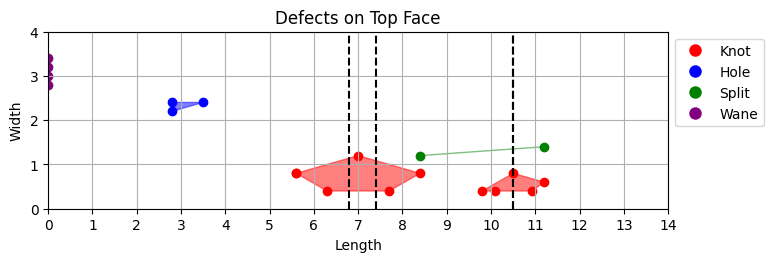

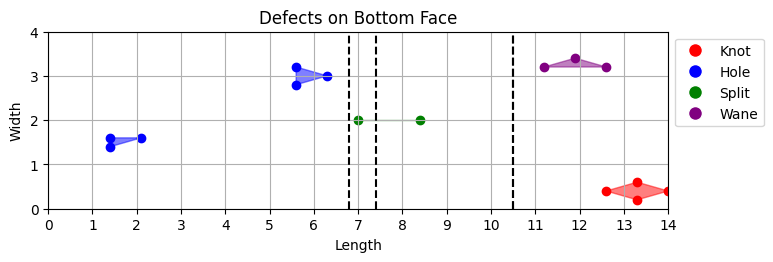

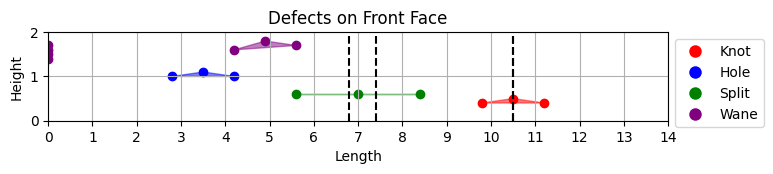

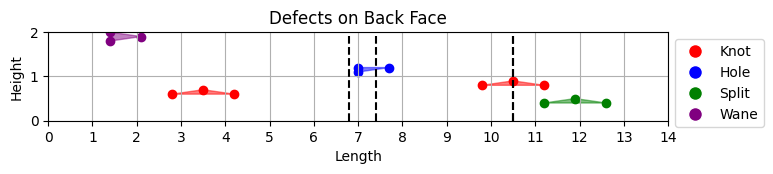

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def calculate_intersections_with_vertical_line(shape, x):
    """Find the y-intersections of a polygon with a vertical line at x."""
    intersections = []
    for i in range(len(shape)):
        j = (i + 1) % len(shape)
        x1, y1 = shape[i]
        x2, y2 = shape[j]
        
        # Check if the edge crosses the vertical line x=n
        if (x1 <= x <= x2) or (x2 <= x <= x1):
            if x1 != x2:  # Avoid division by zero
                # Calculate the y-coordinate of the intersection
                y_intersection = y1 + (x - x1) * (y2 - y1) / (x2 - x1)
                intersections.append(y_intersection)
                
    return intersections

def sum_defect_length_at_n(defects, n, length, width, threshold1, threshold2):
    """Calculate the total length of defects at a vertical line x=n for each defect individually."""
    total_length = 0
    for defect in defects:
        defect_type, position, shape, defect_face = defect  # Unpack defect info
        
        if defect_type in [1, 2]:  # Only consider Knots (1) and Holes (2)
            # Convert defect shape to absolute coordinates
            shape = np.array(shape)  # Ensure shape is a NumPy array
            shape[:, 0] *= length
            shape[:, 1] *= width

            # Check if the defect is a knot and is near the edge
            apply_threshold = threshold1  # Default threshold for knots
            if defect_type == 1:  # Knot defect
                # Check if any part of the knot is near the edge
                if np.any(shape[:, 0] < 0.1) or np.any(shape[:, 0] > length - 0.1):
                    apply_threshold = threshold2  # Apply threshold2 if knot is near the edge

            # For holes, always apply threshold2
            if defect_type == 2:
                apply_threshold = threshold2

            # Find the intersections with the vertical line at x=n
            intersections = calculate_intersections_with_vertical_line(shape, n)
            
            # If there are multiple intersection points, calculate the length for this defect
            if len(intersections) > 1:
                intersections.sort()  # Sort the y-intersections
                for i in range(0, len(intersections), 2):  # Pair up intersections within the same defect
                    if i + 1 < len(intersections):
                        total_length += abs(intersections[i+1] - intersections[i])  # Calculate length between pairs

    return total_length

def plot_single_face_with_defects(length, width, height, defects, face='top', threshold1=0.18, threshold2=0.18):
    fig, ax = plt.subplots(figsize=(8, 8))
    defect_colors = {
        1: 'red',    # Knot
        2: 'blue',   # Hole
        3: 'green',  # Wane
        4: 'purple', # Split
    }

    # Set the limits and labels based on the selected face
    if face == 'upper_wide':
        ax.set_title('Defects on Top Face')
        ax.set_xlim([0, length])  # Keep the real scale for length
        ax.set_ylim([0, width])   # Keep the real scale for width
        ax.set_xlabel('Length')
        ax.set_ylabel('Width')

    elif face == 'bottom_wide':
        ax.set_title('Defects on Bottom Face')
        ax.set_xlim([0, length])  # Keep the real scale for length
        ax.set_ylim([0, width])   # Keep the real scale for width
        ax.set_xlabel('Length')
        ax.set_ylabel('Width')

    elif face == 'front_narrow':
        ax.set_title('Defects on Front Face')
        ax.set_xlim([0, length])  # Keep the real scale for length
        ax.set_ylim([0, height])  # Keep the real scale for height
        ax.set_xlabel('Length')
        ax.set_ylabel('Height')

    elif face == 'back_narrow':
        ax.set_title('Defects on Back Face')
        ax.set_xlim([0, length])  # Keep the real scale for length
        ax.set_ylim([0, height])  # Keep the real scale for height
        ax.set_xlabel('Length')
        ax.set_ylabel('Height')

    # Plot the grid contours (optional)
    ax.set_xticks(np.arange(0, length+1, 1))  # Grid lines for x (length)
    if face in ['upper_wide', 'bottom_wide']:
        ax.set_yticks(np.arange(0, width+1, 1))  # Grid lines for y (width)
    else:
        ax.set_yticks(np.arange(0, height+1, 1))  # Grid lines for y (height)
    ax.grid(True)

    # Plot the defects on the selected face
    for defect in defects:
        defect_type, position, shape, defect_face = defect  # Unpack defect info
        if defect_face == face:  # Only plot for the current face
            color = defect_colors.get(defect_type, 'black')
            shape = np.array(shape)

            # Convert coordinates to absolute values based on the current face
            shape[:, 0] *= length  # Scale x by length
            if face in ['upper_wide', 'bottom_wide']:
                shape[:, 1] *= width   # Scale y by width
            else:
                shape[:, 1] *= height  # Scale y by height

            # Plot the defect shape as a polygon
            ax.fill(shape[:, 0], shape[:, 1], color=color, alpha=0.5)
            ax.scatter(shape[:, 0], shape[:, 1], color=color, marker='o')  # Optional: plot defect center

    # Step 2: Sum defect lengths along x=n for n in [0, xmax]
    n_values = np.arange(0, length, 0.1)
    lengths = [sum_defect_length_at_n(defects, n, length, width if face in ['upper_wide', 'bottom_wide'] else height, threshold1, threshold2) for n in n_values]

    # Step 3: Check if defect length exceeds threshold
    regions_above_threshold = []
    in_region = False
    start_n = None

    for i, length_at_n in enumerate(lengths):
        # Calculate threshold length at this position: threshold * cross-section width
        threshold_length = (threshold1 if length_at_n > threshold2 else threshold2) * (width if face in ['upper_wide', 'bottom_wide'] else height)
        
        # Check if the length exceeds the threshold for this cross-section
        if length_at_n > threshold_length:  # If the defect length exceeds the threshold
            if not in_region:
                start_n = n_values[i]
                in_region = True
        elif length_at_n <= threshold_length and in_region:
            regions_above_threshold.append((start_n, n_values[i-1]))
            in_region = False

    # Plot dashed lines for regions above threshold
    for start_n, end_n in regions_above_threshold:
        ax.axvline(x=start_n, color='black', linestyle='--')
        ax.axvline(x=end_n, color='black', linestyle='--')

    # Set aspect ratio to be equal so that the grid and defect shapes maintain the same scale
    ax.set_aspect('equal', adjustable='box')

    # Create the legend with defect type colors and move it outside the grid
    handles = []
    for color in defect_colors.values():
        handle = plt.Line2D([0], [0], marker='o', color='w', label=color, markersize=10, markerfacecolor=color)
        handles.append(handle)
    
    # Position legend outside the plot on the right
    ax.legend(handles=handles, labels=['Knot', 'Hole', 'Split', 'Wane'], loc='upper left', bbox_to_anchor=(1, 1))

    # Show the plot
    plt.show()

defects = [
    #defect information
]

length = 14
width = 4
height = 2

plot_single_face_with_defects(length, width, height, defects, face='upper_wide')
plot_single_face_with_defects(length, width, height, defects, face='bottom_wide')
plot_single_face_with_defects(length, width, height, defects, face='front_narrow')
plot_single_face_with_defects(length, width, height, defects, face='back_narrow')


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Constants
LUMBER_LENGTH_INCH = 96
LUMBER_WIDTH_INCH = 8

# Thresholds
THRESHOLDS = {
    'knot_touching_edge': [0.5, 1.0, 1.5],
    'knot_not_touching_edge': [1.0, 1.5, 2.0],
}
GRADE_LABELS = ["No.1 Better", "No.1", "No.2", "No.3"]

# === Functions ===
def pixel_to_inches(contour, img_height_px, real_height_in):
    return [(x / img_height_px * real_height_in, y / img_height_px * real_height_in) for x, y in contour]

def get_length_size(contour):
    xs = [pt[0] for pt in contour]
    return max(xs) - min(xs)

def touches_edge(contour):
    return any(x <= 0 or x >= LUMBER_LENGTH_INCH for x, _ in contour)

def overlaps(contour1, contour2):
    x1_min = min(p[0] for p in contour1)
    x1_max = max(p[0] for p in contour1)
    x2_min = min(p[0] for p in contour2)
    x2_max = max(p[0] for p in contour2)
    return not (x1_max < x2_min or x2_max < x1_min)

def evaluate_severity(value, thresholds):
    if value <= thresholds[0]:
        return 0
    elif value <= thresholds[1]:
        return 1
    elif value <= thresholds[2]:
        return 2
    else:
        return 3

def extract_yellow_contours(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([45, 255, 255])
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

def visualize_defects(contours):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_xlim(0, LUMBER_LENGTH_INCH)
    ax.set_ylim(0, LUMBER_WIDTH_INCH)
    ax.invert_yaxis()  # Flip y-axis so top of board is top of plot
    ax.set_aspect('equal')
    ax.set_title("Detected Knot Contours")

    for cnt in contours:
        poly = Polygon(cnt, closed=True, fill=True, color='orange', alpha=0.5)
        ax.add_patch(poly)

    plt.xlabel('Length (inches)')
    plt.ylabel('Width (inches)')
    plt.show()

def assign_grade_from_contours(contours):
    max_severity = 0
    knot_zones = []

    for contour in contours:
        length_size = get_length_size(contour)
        if touches_edge(contour):
            severity = evaluate_severity(length_size, THRESHOLDS['knot_touching_edge'])
        else:
            overlap_found = False
            for other in knot_zones:
                if overlaps(contour, other):
                    total_len = get_length_size(contour) + get_length_size(other)
                    severity = evaluate_severity(total_len, THRESHOLDS['knot_not_touching_edge'])
                    overlap_found = True
                    break
            if not overlap_found:
                severity = evaluate_severity(length_size, THRESHOLDS['knot_not_touching_edge'])
        knot_zones.append(contour)
        max_severity = max(max_severity, severity)

    return GRADE_LABELS[max_severity]

# === Main Workflow ===
def process_image_and_grade(image_path, real_height_in):
    img = cv2.imread(image_path)
    img_height_px = img.shape[0]

    raw_contours = extract_yellow_contours(img)
    converted_contours = []
    for cnt in raw_contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 1: continue
        cnt_inch = pixel_to_inches(cnt, img_height_px, real_height_in)
        converted_contours.append(cnt_inch)

    visualize_defects(converted_contours)
    grade = assign_grade_from_contours(converted_contours)
    print(f"Assigned Grade: {grade}")
    return grade

# === Example Call ===
# Provide the image path and actual board height in inches (e.g., 4)
# grade = process_image_and_grade("sample_knot_image.jpg", real_height_in=4)


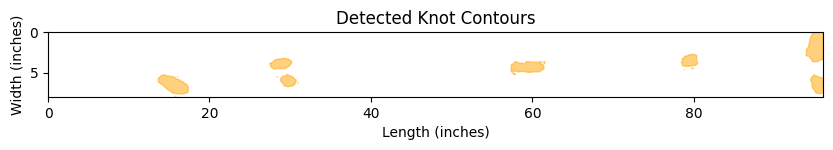

Assigned Grade: No.3
Final Lumber Grade: No.3


In [24]:
if __name__ == "__main__":
    # Example image path (replace with your actual file)
    image_path = "defect overview"

    # Real-world height of the lumber board in inches (e.g., 4-inch wide board)
    real_height_in = 8

    # Run grading
    assigned_grade = process_image_and_grade(image_path, real_height_in)
    print("Final Lumber Grade:", assigned_grade)


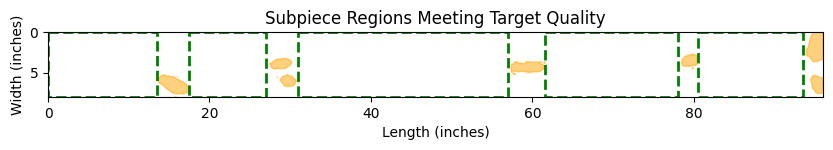

Acceptable Subpiece Regions (inches):
From 0.0 to 13.5 inches
From 17.5 to 27.0 inches
From 31.0 to 57.0 inches
From 61.5 to 78.0 inches
From 80.5 to 93.5 inches


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Constants
LUMBER_LENGTH_INCH = 96
LUMBER_WIDTH_INCH = 8

# Thresholds for grading knots
THRESHOLDS = {
    'knot_touching_edge': [0.5, 1.0, 1.5],
    'knot_not_touching_edge': [1.0, 1.5, 2.0],
}
GRADE_LABELS = ["No.1 Better", "No.1", "No.2", "No.3"]

# === Utility Functions ===

def pixel_to_inches(contour, img_height_px, real_height_in):
    return [(x / img_height_px * real_height_in, y / img_height_px * real_height_in) for x, y in contour]

def get_length_size(contour):
    xs = [pt[0] for pt in contour]
    return max(xs) - min(xs)

def touches_edge(contour):
    return any(x <= 0 or x >= LUMBER_LENGTH_INCH for x, _ in contour)

def overlaps(contour1, contour2):
    x1_min = min(p[0] for p in contour1)
    x1_max = max(p[0] for p in contour1)
    x2_min = min(p[0] for p in contour2)
    x2_max = max(p[0] for p in contour2)
    return not (x1_max < x2_min or x2_max < x1_min)

def evaluate_severity(value, thresholds):
    if value <= thresholds[0]:
        return 0
    elif value <= thresholds[1]:
        return 1
    elif value <= thresholds[2]:
        return 2
    else:
        return 3

# === Contour Extraction ===

def extract_yellow_contours(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([45, 255, 255])
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

# === Grading Functions ===

def assign_grade_from_contours(contours):
    max_severity = 0
    knot_zones = []

    for contour in contours:
        length_size = get_length_size(contour)
        if touches_edge(contour):
            severity = evaluate_severity(length_size, THRESHOLDS['knot_touching_edge'])
        else:
            overlap_found = False
            for other in knot_zones:
                if overlaps(contour, other):
                    total_len = get_length_size(contour) + get_length_size(other)
                    severity = evaluate_severity(total_len, THRESHOLDS['knot_not_touching_edge'])
                    overlap_found = True
                    break
            if not overlap_found:
                severity = evaluate_severity(length_size, THRESHOLDS['knot_not_touching_edge'])

        knot_zones.append(contour)
        max_severity = max(max_severity, severity)

    return GRADE_LABELS[max_severity]

def assign_grade_in_window(contours, x_start, x_end):
    sub_contours = []
    for cnt in contours:
        if any(x_start <= x <= x_end for x, _ in cnt):
            sub_contours.append(cnt)
    return assign_grade_from_contours(sub_contours)

# === Subpiece Evaluation ===

def find_acceptable_regions(contours, target_quality_index, window_size=1.0, step_size=0.5):
    acceptable_regions = []
    x = 0.0
    while x + window_size <= LUMBER_LENGTH_INCH:
        grade = assign_grade_in_window(contours, x, x + window_size)
        grade_index = GRADE_LABELS.index(grade)
        if grade_index <= target_quality_index:
            acceptable_regions.append((x, x + window_size))
        x += step_size
    return acceptable_regions

# === Visualization ===
def merge_regions(region_list):
    if not region_list:
        return []
    region_list.sort()
    merged = [region_list[0]]
    for current_start, current_end in region_list[1:]:
        last_start, last_end = merged[-1]
        if current_start <= last_end:  # overlapping or adjacent
            merged[-1] = (last_start, max(last_end, current_end))
        else:
            merged.append((current_start, current_end))
    return merged
    
def visualize_defects_with_subpieces(contours, accepted_regions):
    merged_regions = merge_regions(accepted_regions)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_xlim(0, LUMBER_LENGTH_INCH)
    ax.set_ylim(0, LUMBER_WIDTH_INCH)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title("Subpiece Regions Meeting Target Quality")

    for cnt in contours:
        poly = Polygon(cnt, closed=True, fill=True, color='orange', alpha=0.5)
        ax.add_patch(poly)

    for x_start, x_end in merged_regions:
        rect = plt.Rectangle((x_start, 0), x_end - x_start, LUMBER_WIDTH_INCH,
                             linewidth=2, edgecolor='green', facecolor='none', linestyle='--')
        ax.add_patch(rect)

    plt.xlabel('Length (inches)')
    plt.ylabel('Width (inches)')
    plt.show()

# === Main Execution ===

def process_image_and_subpiece_grading(image_path, real_height_in, target_quality_label="No.1"):
    img = cv2.imread(image_path)
    img_height_px = img.shape[0]

    raw_contours = extract_yellow_contours(img)
    converted_contours = []
    for cnt in raw_contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 1: continue
        cnt_inch = pixel_to_inches(cnt, img_height_px, real_height_in)
        converted_contours.append(cnt_inch)

    target_quality_index = GRADE_LABELS.index(target_quality_label)
    accepted_regions = find_acceptable_regions(converted_contours, target_quality_index)
    visualize_defects_with_subpieces(converted_contours, accepted_regions)
    return accepted_regions

# === Example Call ===

if __name__ == "__main__":
    image_path = "defect"  # Replace with your actual image path
    real_height_in = 8                    # Actual board height in inches
    target_quality = "No.1"              # Choose from GRADE_LABELS

    regions = process_image_and_subpiece_grading(image_path, real_height_in, target_quality_label=target_quality)

    # Merge and print final acceptable subpieces
    merged_regions = merge_regions(regions)
    print("Acceptable Subpiece Regions (inches):")
    for start, end in merged_regions:
        print(f"From {start:.1f} to {end:.1f} inches")

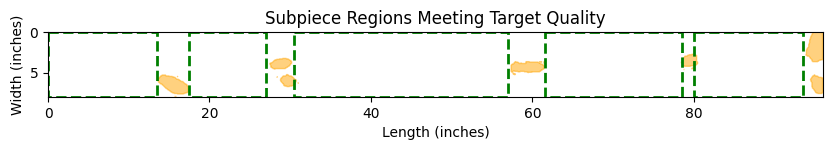

Acceptable Subpiece Regions (inches):
From 0.0 to 13.5 inches
From 17.5 to 27.0 inches
From 30.5 to 57.0 inches
From 61.5 to 78.5 inches
From 80.0 to 93.5 inches


In [28]:
if __name__ == "__main__":
    image_path = "defect"  # Replace with your actual image path
    real_height_in = 8                    # Actual board height in inches
    target_quality = "No.2"              # Choose from GRADE_LABELS

    regions = process_image_and_subpiece_grading(image_path, real_height_in, target_quality_label=target_quality)

    # Merge and print final acceptable subpieces
    merged_regions = merge_regions(regions)
    print("Acceptable Subpiece Regions (inches):")
    for start, end in merged_regions:
        print(f"From {start:.1f} to {end:.1f} inches")

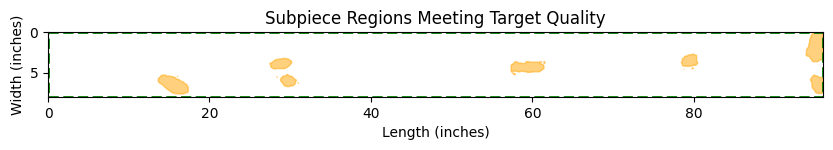

Acceptable Subpiece Regions (inches):
From 0.0 to 96.0 inches


In [27]:
if __name__ == "__main__":
    image_path = "defect"  # Replace with your actual image path
    real_height_in = 8                    # Actual board height in inches
    target_quality = "No.3"              # Choose from GRADE_LABELS

    regions = process_image_and_subpiece_grading(image_path, real_height_in, target_quality_label=target_quality)

    # Merge and print final acceptable subpieces
    merged_regions = merge_regions(regions)
    print("Acceptable Subpiece Regions (inches):")
    for start, end in merged_regions:
        print(f"From {start:.1f} to {end:.1f} inches")